# Kolm tüüpi III samba uut kogujat

**Cohort:** 6,421 inimest, kes alustasid Tulevas kogumist III sambaga ajavahemikus 2025-01-01 → 2026-04-30. See on ~50% kõigist Tuleva uutest kogujatest sel perioodil.

Cohort jaguneb kolme selgelt eristuvasse rühma. Iga rühma juures näitame **jaotusi**, mitte keskmisi — keskmine peidab tegelikku heterogeensust.


In [1]:
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root / 'common' / 'scripts'))
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE
setup_plot_style()

CACHE_DIR = Path(os.environ.get('TULEVA_CACHE_DIR', Path.home() / '.cache' / 'tuleva-reports'))
df_crm = pd.read_pickle(CACHE_DIR / 'card_2345_crm.pkl')
for c in df_crm.columns:
    if 'Date' in c or 'Month' in c:
        df_crm[c] = pd.to_datetime(df_crm[c], errors='coerce')

COHORT_START = pd.Timestamp('2025-01-01')
COHORT_END   = pd.Timestamp('2026-04-30')

df_crm['iii_min'] = df_crm['Third Pillar Min Contribution Date']
df_crm['ii_first_in'] = df_crm[['Tuk75 Min Reporting Date', 'Tuk00 Min Reporting Date']].min(axis=1)

cohort = df_crm[
    df_crm['iii_min'].notna()
    & (df_crm['iii_min'] >= COHORT_START)
    & (df_crm['iii_min'] <= COHORT_END)
].copy()
cohort['iii_only_start'] = cohort['ii_first_in'].isna() | (cohort['ii_first_in'] > cohort['iii_min'])
cs = cohort[cohort['iii_only_start']].copy()

cs['left_ii'] = cs['Early Withdrawal Status'].isin(['R', 'A'])
cs['voluntary_rate'] = cs['Current Rate'].fillna(0) > 2
cs['iii_l12m'] = cs['Third Pillar Last 12m Contributions Sum'].fillna(0)
cs['total_aum'] = cs[['Third Pillar Current Aum', 'Tuk75 Current Aum', 'Tuk00 Current Aum']].sum(axis=1)

cs['segment'] = np.select(
    [
        cs['left_ii'],
        cs['voluntary_rate'] | (cs['iii_l12m'] >= 1000),
    ],
    ['Single Pillar', 'Aktiivne'],
    default='Passiivne'
)

n_total = len(cs)
SEG_ORDER  = ['Aktiivne', 'Single Pillar', 'Passiivne']
SEG_COLORS = {'Aktiivne': TULEVA_NAVY, 'Single Pillar': '#FF8C00', 'Passiivne': '#FFC04D'}

age_bins = [0, 30, 40, 50, 60, 200]
age_labels = ['alla 30', '30-39', '40-49', '50-59', '60+']
cs['age_grp'] = pd.cut(cs['Age'], bins=age_bins, labels=age_labels, right=False)

iii_bins = [-0.01, 100, 1000, 2000, np.inf]
iii_labels = ['alla 100 €', '100–1000 €', '1000–2000 €', 'üle 2000 €']
cs['iii_bucket'] = pd.cut(cs['iii_l12m'], bins=iii_bins, labels=iii_labels)

def rate_label(r):
    if pd.isna(r): return 'Teadmata'
    if r == 2: return '2%'
    if r == 4: return '4%'
    if r == 6: return '6%'
    return 'Muu'
cs['rate_grp'] = cs['Current Rate'].apply(rate_label)

print(f'Cohort kokku: {n_total:,}')
for seg in SEG_ORDER:
    sub = cs[cs['segment'] == seg]
    print(f'  {seg:15s}  {len(sub):>5,}  ({len(sub)/n_total*100:.0f}%)')

Cohort kokku: 6,421
  Aktiivne         2,816  (44%)
  Single Pillar    1,795  (28%)
  Passiivne        1,810  (28%)


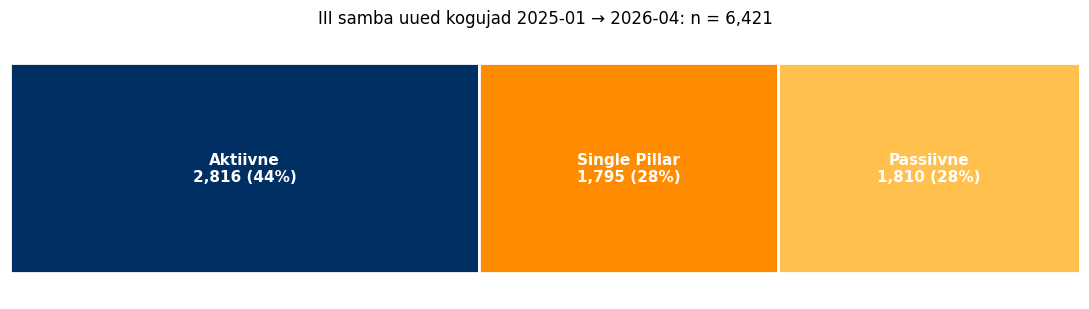

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
x = 0
for seg in SEG_ORDER:
    n = (cs['segment'] == seg).sum()
    ax.barh(0, n, left=x, color=SEG_COLORS[seg], edgecolor='white', linewidth=2)
    pct = n / n_total * 100
    ax.text(x + n/2, 0, f'{seg}\n{n:,} ({pct:.0f}%)', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    x += n
ax.set_xlim(0, n_total)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f'III samba uued kogujad 2025-01 → 2026-04: n = {n_total:,}', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## 1. Aktiivne säästja — 44% (2,816 inimest)

Inimesed, kellel on II sambas vabatahtlik kõrgem maksemäär (4% või 6%), **või** kes panevad III sambasse vähemalt 1,000 € aastas. Need on inimesed, kelle jaoks kogumine on teadlik strateegiline valik — kasutavad mõlemat sammast samasuguse loogikaga.

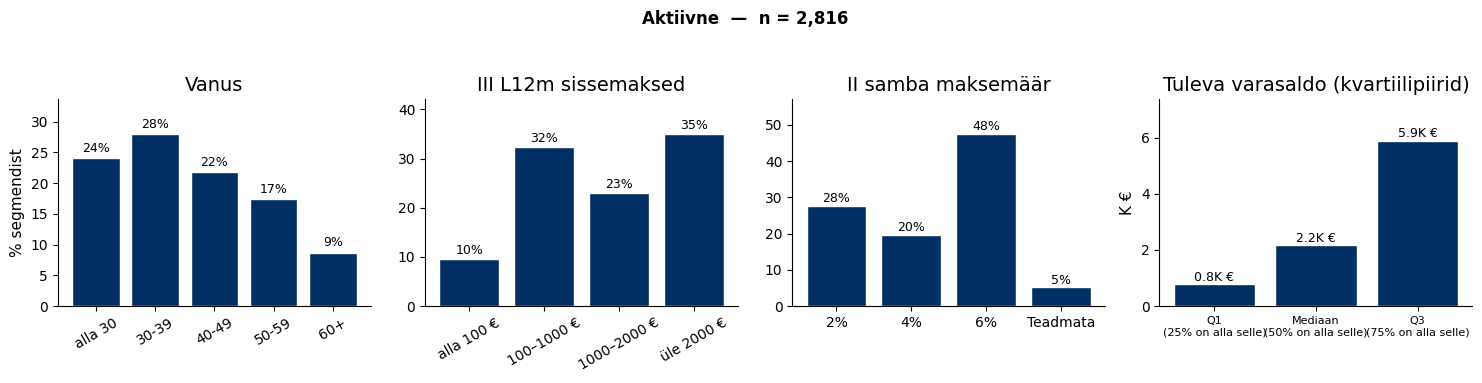

In [3]:
def profile_chart(seg, color):
    sub = cs[cs['segment'] == seg]
    n_seg = len(sub)
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
    
    ax = axes[0]
    age_d = (sub['age_grp'].value_counts(normalize=True).reindex(age_labels) * 100).fillna(0)
    ax.bar(age_labels, age_d.values, color=color, edgecolor='white')
    for i, v in enumerate(age_d.values):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
    ax.set_title('Vanus')
    ax.set_ylabel('% segmendist')
    ax.set_ylim(0, max(age_d.max(), 5) * 1.2)
    ax.tick_params(axis='x', rotation=30)
    
    ax = axes[1]
    iii_d = (sub['iii_bucket'].value_counts(normalize=True).reindex(iii_labels) * 100).fillna(0)
    ax.bar(iii_labels, iii_d.values, color=color, edgecolor='white')
    for i, v in enumerate(iii_d.values):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
    ax.set_title('III L12m sissemaksed')
    ax.set_ylim(0, max(iii_d.max(), 5) * 1.2)
    ax.tick_params(axis='x', rotation=30)
    
    ax = axes[2]
    rate_order = ['2%', '4%', '6%', 'Teadmata']
    rate_d = (sub['rate_grp'].value_counts(normalize=True).reindex(rate_order) * 100).fillna(0)
    ax.bar(rate_order, rate_d.values, color=color, edgecolor='white')
    for i, v in enumerate(rate_d.values):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
    ax.set_title('II samba maksemäär')
    ax.set_ylim(0, max(rate_d.max(), 5) * 1.2)
    
    ax = axes[3]
    aum = sub['total_aum'][sub['total_aum'] > 0]
    if len(aum) > 0:
        q = aum.quantile([0.25, 0.5, 0.75]).values
        labels = [
            'Q1\n(25% on alla selle)',
            'Mediaan\n(50% on alla selle)',
            'Q3\n(75% on alla selle)',
        ]
        ax.bar(labels, q / 1000, color=color, edgecolor='white')
        for i, v in enumerate(q):
            ax.text(i, v/1000 + max(q)/1000*0.02, f'{v/1000:.1f}K €', ha='center', fontsize=9)
        ax.set_title('Tuleva varasaldo (kvartiilipiirid)')
        ax.set_ylabel('K €')
        ax.set_ylim(0, max(q)/1000 * 1.25)
        ax.tick_params(axis='x', labelsize=8)
    
    plt.suptitle(f'{seg}  —  n = {n_seg:,}', fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

profile_chart('Aktiivne', TULEVA_NAVY)

**Mis neid iseloomustab:**
- Vanus jaotub laiali kogu tööea ulatuses: 24% on alla 30, 28% 30-39, 22% 40-49 ja 26% üle 50. See ei ole kindel demograafia, vaid pigem käitumismuster.
- III sissemaksed on tugevad: **35% segmendist paneb III sambasse üle 2000 € aastas, 23% 1000-2000 €**. Veel 32% on 100-1000 € vahemikus — neil aitab "aktiivne" tiitlit hoida vabatahtlik II maksemäär.
- II samba maksemäär: **48% on 6%-l ja 20% 4%-l**. Ülejäänud 28%, kes on jäänud 2% peale, kuuluvad sellesse segmenti suurte III sissemaksete tõttu.
- Tuleva varasaldo: alumine kvartiil 0.8K €, mediaan 2.2K €, ülemine kvartiil 5.9K € — segment kannab juba reaalset Tuleva AUM-i.
- Püsimaksega ~29%.
- **18.7% segmendist on pärast III sambaga liitumist toonud ka oma II samba Tulevasse** (526 inimest, kokku 6.3 M € II AUM-i).


## 2. Single Pillar — 28% (1,795 inimest)

Inimesed, kes on II sambast lahkunud (Early Withdrawal staatus R või A) ja kellel on Tulevas ainult III sammas. Neil ei ole struktuurselt võimalik II sammast Tulevasse tuua — III on pensionivara ainus kanal.

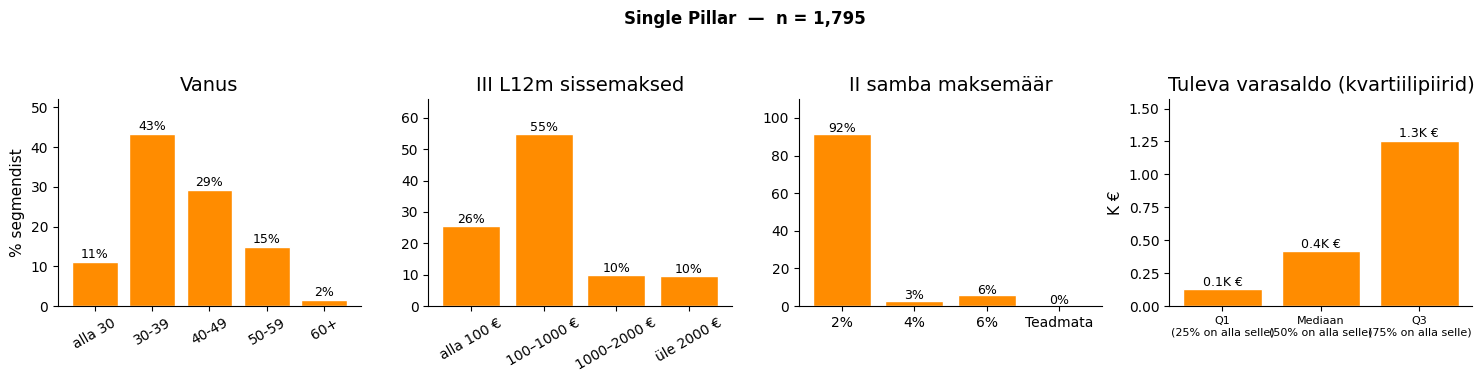

In [4]:
profile_chart('Single Pillar', '#FF8C00')

**Mis neid iseloomustab:**
- Vanus on selgelt **30-49 fookuses (72% segmendist)** — sama generatsioon, kes 2021-2022 aastatel kasutas II samba väljavõtmise õigust.
- Sissemakse jaotus: **26% segmendist teeb III sambasse alla 100 € aastas ja 55% jääb 100-1000 € vahemikku**. Ülejäänud 20% on suuremate sissemaksetega (1000+). Kuigi neil pole muud pensionivara, ei ole sissemaksed siiski tugevad.
- Varasaldo: Q1 130 €, mediaan 420 €, Q3 1.3K € — vara akumuleerub aeglaselt.
- Püsimaksega 31% — samaväärselt aktiivsetega. See viitab, et segment on tegelikult süsteemselt seadistanud kogumise, lihtsalt madalama mahuga.


## 3. Passiivne alustaja — 28% (1,810 inimest)

Inimesed, kellel on II sammas alles ja maksemäär on jäänud 2% peale **ja** III sambasse panevad alla 1000 € aastas. Need on inimesed, kes tegid Tulevas konto lahti, aga reaalne säästmine pole veel käivitunud.

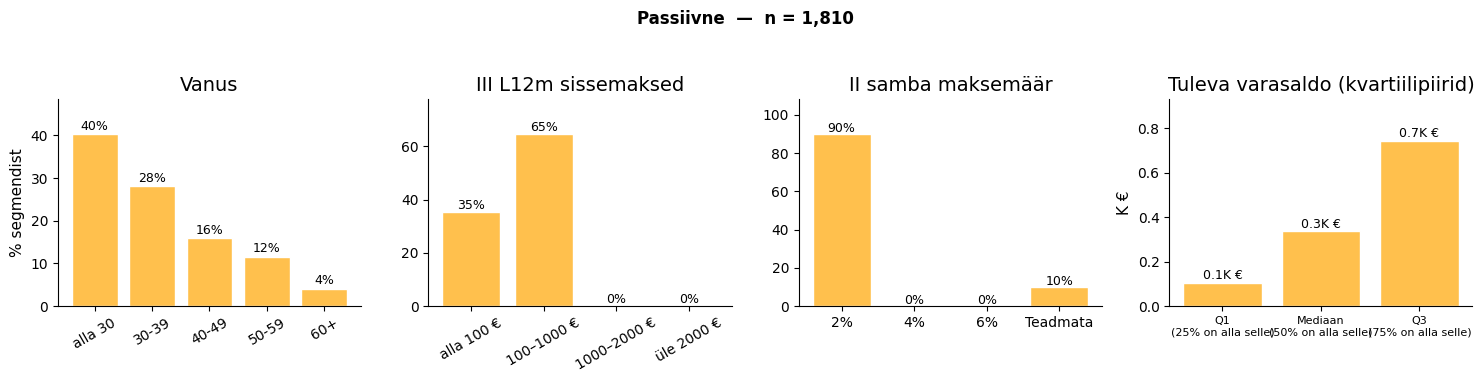

In [5]:
profile_chart('Passiivne', '#FFC04D')

**Mis neid iseloomustab:**
- Märgatavalt nooremad — **40% on alla 30 ja veel 28% 30-39 vahel** (kokku 68% alla 40-aastased). Tuleva III sammas on neile tõnäoliselt esmane tutvus pensionisüsteemiga.
- III sissemaksed on tagasihoidlikud: **35% segmendist paneb alla 100 € aastas, 65% jääb 100-1000 € vahemikku**. Definitsiooni järgi pole kedagi üle 1000 €.
- II samba maksemäär: **90% on 2% peal**, ülejäänutel määr puudub. Definitsiooni järgi ei ole kedagi vabatahtlikul kõrgemal määral.
- Varasaldo on tagasihoidlik: Q1 ~110 €, mediaan ~340 €, Q3 ~740 €.
- Püsimaksega ainult 21% — vähim kõigi segmentide hulgas.
- **13.6% segmendist on pärast III sambaga liitumist toonud ka oma II samba Tulevasse** (246 inimest, kokku 1.3 M € II AUM-i) — peaaegu kolmandiku võrra madalam määr kui aktiivsetel.



## Kõrvutus


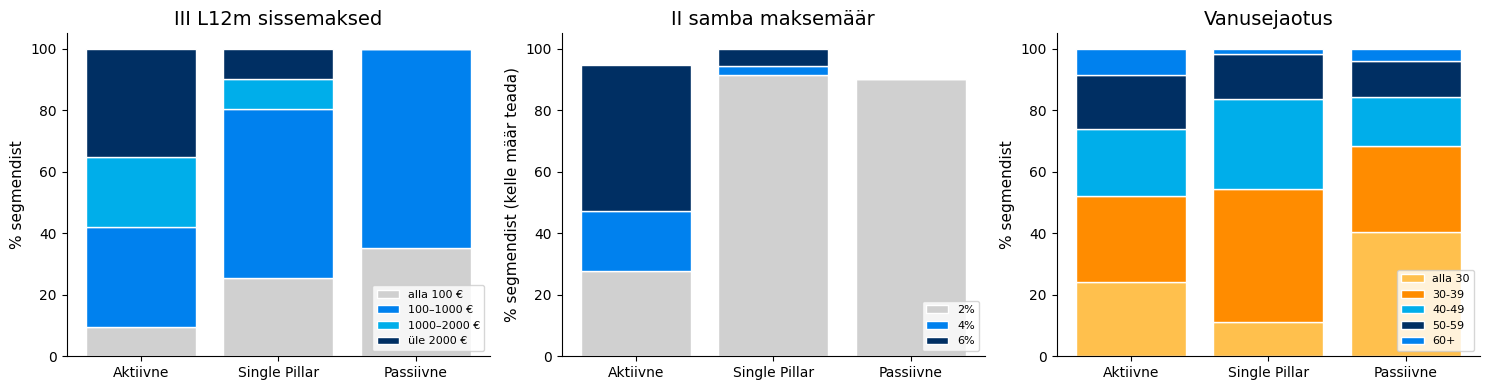

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(SEG_ORDER))

ax = axes[0]
iii_dist = pd.DataFrame({
    seg: (cs[cs['segment'] == seg]['iii_bucket'].value_counts(normalize=True).reindex(iii_labels) * 100).fillna(0).values
    for seg in SEG_ORDER
}, index=iii_labels)
bottom = np.zeros(len(SEG_ORDER))
bucket_colors = ['#D0D0D0', TULEVA_MID_BLUE, TULEVA_BLUE, TULEVA_NAVY]
for label, color in zip(iii_labels, bucket_colors):
    vals = iii_dist.loc[label].values
    ax.bar(SEG_ORDER, vals, bottom=bottom, label=label, color=color, edgecolor='white')
    bottom += vals
ax.set_ylabel('% segmendist')
ax.set_title('III L12m sissemaksed')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 105)

ax = axes[1]
rate_order = ['2%', '4%', '6%']
rate_dist = pd.DataFrame({
    seg: (cs[cs['segment'] == seg]['rate_grp'].value_counts(normalize=True).reindex(rate_order) * 100).fillna(0).values
    for seg in SEG_ORDER
}, index=rate_order)
bottom = np.zeros(len(SEG_ORDER))
rate_colors = ['#D0D0D0', TULEVA_MID_BLUE, TULEVA_NAVY]
for label, color in zip(rate_order, rate_colors):
    vals = rate_dist.loc[label].values
    ax.bar(SEG_ORDER, vals, bottom=bottom, label=label, color=color, edgecolor='white')
    bottom += vals
ax.set_ylabel('% segmendist (kelle määr teada)')
ax.set_title('II samba maksemäär')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 105)

ax = axes[2]
age_dist_seg = pd.DataFrame({
    seg: (cs[cs['segment'] == seg]['age_grp'].value_counts(normalize=True).reindex(age_labels) * 100).fillna(0).values
    for seg in SEG_ORDER
}, index=age_labels)
bottom = np.zeros(len(SEG_ORDER))
age_colors = ['#FFC04D', '#FF8C00', TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE]
for label, color in zip(age_labels, age_colors):
    vals = age_dist_seg.loc[label].values
    ax.bar(SEG_ORDER, vals, bottom=bottom, label=label, color=color, edgecolor='white')
    bottom += vals
ax.set_ylabel('% segmendist')
ax.set_title('Vanusejaotus')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()